# UrbanFlow — AI/ML-Based Traffic Prediction System

## 01. Data Understanding

This notebook represents the first technical stage of the UrbanFlow project.

### Project Goal

UrbanFlow aims to analyze historical traffic sensor data and develop an AI/ML-based system capable of predicting future traffic speed and identifying potential congestion.

### Objectives of This Notebook

- Understand the structure of the METR-LA traffic dataset.
- Identify the number and nature of traffic sensors.
- Examine the time-series characteristics of the data.
- Understand the traffic measurements and their organization.
- Prepare the foundation for data preprocessing and exploratory data analysis.

### Dataset

**METR-LA Traffic Dataset**

The dataset contains historical traffic-speed measurements collected from traffic sensors in the Los Angeles road network.

### Project Workflow

Data Collection → Data Understanding → Preprocessing → Exploratory Data Analysis → Machine Learning → Deep Learning → Traffic Prediction → Dashboard → Deployment

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("UrbanFlow environment is working!")

UrbanFlow environment is working!


In [3]:
import sys

print("Python version:", sys.version)
print("Python executable:", sys.executable)

Python version: 3.13.7 (v3.13.7:bcee1c32211, Aug 14 2025, 19:10:51) [Clang 16.0.0 (clang-1600.0.26.6)]
Python executable: /Users/raginigupta/Desktop/Urbanflow/.venv/bin/python


In [2]:
import pandas as pd

file_path = "../data/raw/metr-la.h5"

with pd.HDFStore(file_path, mode="r") as store:
    print("Keys inside the HDF5 file:")
    print(store.keys())

Keys inside the HDF5 file:
['/df']


In [36]:
df = pd.read_hdf(file_path, key="/df")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

TypeError: a bytes-like object is required, not 'str'

In [5]:
import pandas as pd
import tables

print("Pandas version:", pd.__version__)
print("PyTables version:", tables.__version__)

Pandas version: 3.0.5
PyTables version: 3.11.1


In [6]:
import h5py

with h5py.File(file_path, "r") as f:
    print("Items inside the HDF5 file:")
    
    def show_structure(name):
        print(name)
    
    f.visit(show_structure)

Items inside the HDF5 file:
df
df/axis0
df/axis1
df/block0_items
df/block0_values


In [7]:
with h5py.File(file_path, "r") as f:
    print("axis0 shape:", f["df/axis0"].shape)
    print("axis0 dtype:", f["df/axis0"].dtype)

    print("axis1 shape:", f["df/axis1"].shape)
    print("axis1 dtype:", f["df/axis1"].dtype)

    print("block0_items shape:", f["df/block0_items"].shape)
    print("block0_items dtype:", f["df/block0_items"].dtype)

    print("block0_values shape:", f["df/block0_values"].shape)
    print("block0_values dtype:", f["df/block0_values"].dtype)

axis0 shape: (207,)
axis0 dtype: |S6
axis1 shape: (34272,)
axis1 dtype: int64
block0_items shape: (207,)
block0_items dtype: |S6
block0_values shape: (34272, 207)
block0_values dtype: float64


In [8]:
with h5py.File(file_path, "r") as f:
    sensor_ids = f["df/block0_items"][:]
    timestamps = f["df/axis1"][:]
    values = f["df/block0_values"][:]

print("First 10 sensor IDs:")
print(sensor_ids[:10])

print("\nFirst 10 timestamps:")
print(timestamps[:10])

print("\nFirst 5 rows and 5 sensors of traffic data:")
print(values[:5, :5])

First 10 sensor IDs:
[b'773869' b'767541' b'767542' b'717447' b'717446' b'717445' b'773062'
 b'767620' b'737529' b'717816']

First 10 timestamps:
[1330560000000000000 1330560300000000000 1330560600000000000
 1330560900000000000 1330561200000000000 1330561500000000000
 1330561800000000000 1330562100000000000 1330562400000000000
 1330562700000000000]

First 5 rows and 5 sensors of traffic data:
[[64.375      67.625      67.125      61.5        66.875     ]
 [62.66666667 68.55555556 65.44444444 62.44444444 64.44444444]
 [64.         63.75       60.         59.         66.5       ]
 [ 0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.        ]]


In [9]:
sensor_ids = [sid.decode("utf-8") for sid in sensor_ids]

timestamps_readable = pd.to_datetime(timestamps, unit="ns")

print("First 10 sensor IDs:")
print(sensor_ids[:10])

print("\nFirst 10 readable timestamps:")
print(timestamps_readable[:10])

First 10 sensor IDs:
['773869', '767541', '767542', '717447', '717446', '717445', '773062', '767620', '737529', '717816']

First 10 readable timestamps:
DatetimeIndex(['2012-03-01 00:00:00', '2012-03-01 00:05:00',
               '2012-03-01 00:10:00', '2012-03-01 00:15:00',
               '2012-03-01 00:20:00', '2012-03-01 00:25:00',
               '2012-03-01 00:30:00', '2012-03-01 00:35:00',
               '2012-03-01 00:40:00', '2012-03-01 00:45:00'],
              dtype='datetime64[ns]', freq=None)


In [10]:

traffic_df = pd.DataFrame(
    values,
    index=timestamps_readable,
    columns=sensor_ids
)

print("Dataset shape:")
print(traffic_df.shape)

print("\nFirst 5 rows:")
print(traffic_df.head())

Dataset shape:
(34272, 207)

First 5 rows:
                        773869     767541     767542     717447     717446  \
2012-03-01 00:00:00  64.375000  67.625000  67.125000  61.500000  66.875000   
2012-03-01 00:05:00  62.666667  68.555556  65.444444  62.444444  64.444444   
2012-03-01 00:10:00  64.000000  63.750000  60.000000  59.000000  66.500000   
2012-03-01 00:15:00   0.000000   0.000000   0.000000   0.000000   0.000000   
2012-03-01 00:20:00   0.000000   0.000000   0.000000   0.000000   0.000000   

                        717445  773062  767620     737529     717816  ...  \
2012-03-01 00:00:00  68.750000  65.125  67.125  59.625000  62.750000  ...   
2012-03-01 00:05:00  68.111111  65.000  65.000  57.444444  63.333333  ...   
2012-03-01 00:10:00  66.250000  64.500  64.250  63.875000  65.375000  ...   
2012-03-01 00:15:00   0.000000   0.000   0.000   0.000000   0.000000  ...   
2012-03-01 00:20:00   0.000000   0.000   0.000   0.000000   0.000000  ...   

                        7

In [11]:

print("Dataset shape:")
print(traffic_df.shape)

print("\nData types:")
print(traffic_df.dtypes.value_counts())

print("\nMissing values:")
print(traffic_df.isnull().sum().sum())

print("\nTotal values:")
print(traffic_df.size)

Dataset shape:
(34272, 207)

Data types:
float64    207
Name: count, dtype: int64

Missing values:
0

Total values:
7094304


In [12]:

zero_count = (traffic_df == 0).sum().sum()
total_count = traffic_df.size

zero_percentage = (zero_count / total_count) * 100

print("Total values:", total_count)
print("Zero-speed values:", zero_count)
print("Zero percentage:", round(zero_percentage, 2), "%")

Total values: 7094304
Zero-speed values: 575302
Zero percentage: 8.11 %


In [13]:

zeros_per_sensor = (traffic_df == 0).sum()

print("Top 10 sensors with the most zero values:")
print(zeros_per_sensor.sort_values(ascending=False).head(10))

Top 10 sensors with the most zero values:
718076    6890
716939    6464
760987    5532
716955    5374
769418    5349
769405    5346
717481    5163
717510    5156
717513    4819
717576    4675
dtype: int64


In [14]:

sensor = "718076"

zero_times = traffic_df.index[traffic_df[sensor] == 0]

print("Sensor:", sensor)
print("Number of zero values:", len(zero_times))

print("\nFirst 20 timestamps where speed is zero:")
print(zero_times[:20])

Sensor: 718076
Number of zero values: 6890

First 20 timestamps where speed is zero:
DatetimeIndex(['2012-03-01 00:00:00', '2012-03-01 00:05:00',
               '2012-03-01 00:10:00', '2012-03-01 00:15:00',
               '2012-03-01 00:20:00', '2012-03-01 00:25:00',
               '2012-03-01 00:30:00', '2012-03-01 00:35:00',
               '2012-03-01 00:40:00', '2012-03-01 00:45:00',
               '2012-03-01 00:50:00', '2012-03-01 00:55:00',
               '2012-03-01 01:00:00', '2012-03-01 01:05:00',
               '2012-03-01 01:10:00', '2012-03-01 02:45:00',
               '2012-03-01 02:50:00', '2012-03-01 02:55:00',
               '2012-03-01 03:00:00', '2012-03-01 03:05:00'],
              dtype='datetime64[ns]', freq=None)


In [15]:

sensor = "718076"

is_zero = traffic_df[sensor] == 0

groups = is_zero.ne(is_zero.shift()).cumsum()
zero_runs = is_zero.groupby(groups).sum()

longest_zero_run = int(zero_runs.max())

print("Sensor:", sensor)
print("Longest continuous zero run:", longest_zero_run, "time points")
print("Duration:", longest_zero_run * 5, "minutes")

Sensor: 718076
Longest continuous zero run: 875 time points
Duration: 4375 minutes


In [16]:

sensor = "718076"

is_zero = traffic_df[sensor] == 0
groups = is_zero.ne(is_zero.shift()).cumsum()

zero_runs = is_zero.groupby(groups).sum()
longest_group = zero_runs.idxmax()

longest_zero_start = traffic_df.index[groups == longest_group][0]
longest_zero_end = traffic_df.index[groups == longest_group][-1]

print("Sensor:", sensor)
print("Longest zero run:", int(zero_runs.max()), "time points")
print("Start:", longest_zero_start)
print("End:", longest_zero_end)

Sensor: 718076
Longest zero run: 875 time points
Start: 2012-03-15 09:15:00
End: 2012-03-18 10:05:00


In [17]:

longest_zero_runs = {}

for sensor in traffic_df.columns:
    is_zero = traffic_df[sensor] == 0
    groups = is_zero.ne(is_zero.shift()).cumsum()
    zero_runs = is_zero.groupby(groups).sum()
    
    longest_zero_runs[sensor] = int(zero_runs.max())

longest_zero_runs = pd.Series(longest_zero_runs)

print("Longest zero run across all sensors:")
print(longest_zero_runs.describe())

print("\nTop 10 sensors by longest zero run:")
print(longest_zero_runs.sort_values(ascending=False).head(10))

Longest zero run across all sensors:
count     207.000000
mean      483.473430
std       252.351769
min       381.000000
25%       381.000000
50%       381.000000
75%       396.000000
max      1683.000000
dtype: float64

Top 10 sensors by longest zero run:
717491    1683
717490    1683
769444    1330
769430    1330
769431    1330
769443    1330
759772    1160
716968    1134
718496    1134
774204    1134
dtype: int64


In [18]:

all_zero_runs = []

for sensor in traffic_df.columns:
    is_zero = traffic_df[sensor] == 0
    groups = is_zero.ne(is_zero.shift()).cumsum()
    zero_runs = is_zero.groupby(groups).sum()

    zero_runs = zero_runs[zero_runs > 0]

    all_zero_runs.extend(zero_runs.tolist())

all_zero_runs = pd.Series(all_zero_runs)

print("Total zero runs:", len(all_zero_runs))

print("\nZero runs of 1-6 time points:")
print((all_zero_runs <= 6).sum())

print("\nZero runs of 7-12 time points:")
print(((all_zero_runs >= 7) & (all_zero_runs <= 12)).sum())

print("\nZero runs longer than 12 time points:")
print((all_zero_runs > 12).sum())

print("\nLongest zero run:")
print(int(all_zero_runs.max()), "time points")

Total zero runs: 25963

Zero runs of 1-6 time points:
16559

Zero runs of 7-12 time points:
3149

Zero runs longer than 12 time points:
6255

Longest zero run:
1683 time points


In [19]:

short_runs = (all_zero_runs <= 6).sum()
medium_runs = ((all_zero_runs >= 7) & (all_zero_runs <= 12)).sum()
long_runs = (all_zero_runs > 12).sum()

total_runs = len(all_zero_runs)

print("Short zero runs (1-6 points):", round(short_runs / total_runs * 100, 2), "%")
print("Medium zero runs (7-12 points):", round(medium_runs / total_runs * 100, 2), "%")
print("Long zero runs (>12 points):", round(long_runs / total_runs * 100, 2), "%")

Short zero runs (1-6 points): 63.78 %
Medium zero runs (7-12 points): 12.13 %
Long zero runs (>12 points): 24.09 %


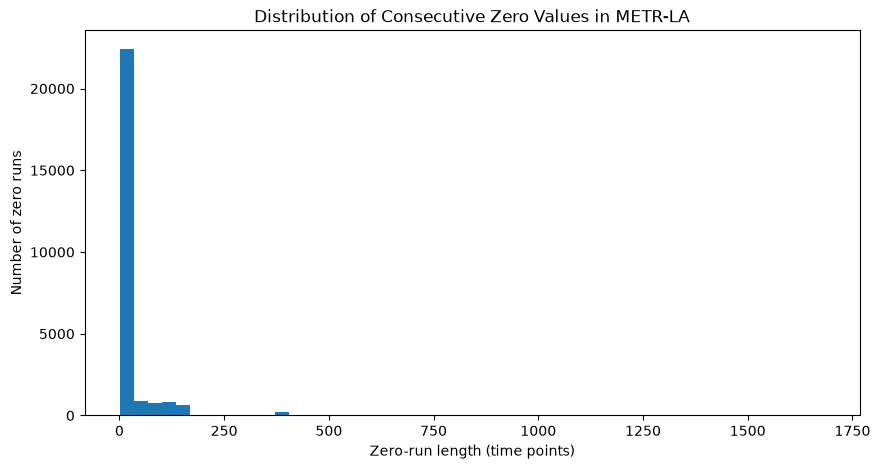

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(all_zero_runs, bins=50)

plt.xlabel("Zero-run length (time points)")
plt.ylabel("Number of zero runs")
plt.title("Distribution of Consecutive Zero Values in METR-LA")

plt.show()

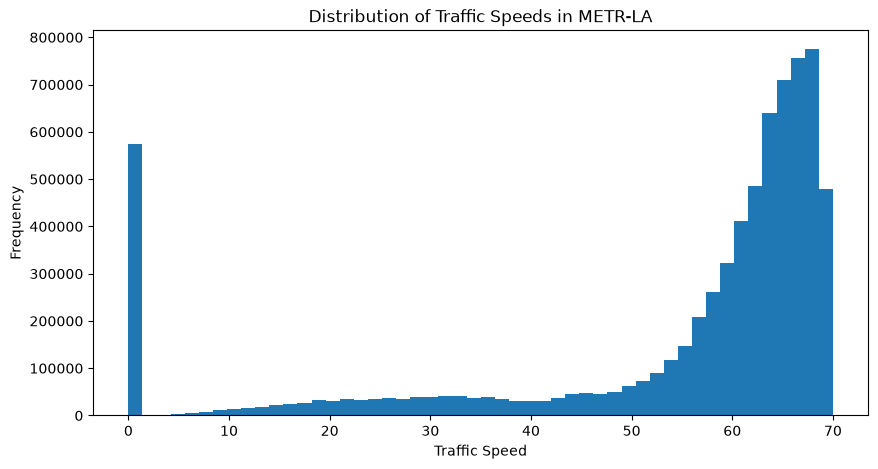

In [25]:

plt.figure(figsize=(10, 5))

plt.hist(traffic_df.values.flatten(), bins=50)

plt.xlabel("Traffic Speed")
plt.ylabel("Frequency")
plt.title("Distribution of Traffic Speeds in METR-LA")

plt.show()

In [28]:

import numpy as np
speed_values = traffic_df.values.flatten()

print("Minimum speed:", speed_values.min())
print("Maximum speed:", speed_values.max())
print("Mean speed:", round(speed_values.mean(), 2))
print("Median speed:", round(np.median(speed_values), 2))
print("Standard deviation:", round(speed_values.std(), 2))

print("\nPercentiles:")
print("25th percentile:", round(np.percentile(speed_values, 25), 2))
print("50th percentile:", round(np.percentile(speed_values, 50), 2))
print("75th percentile:", round(np.percentile(speed_values, 75), 2))

Minimum speed: 0.0
Maximum speed: 70.0
Mean speed: 53.72
Median speed: 62.44
Standard deviation: 20.26

Percentiles:
25th percentile: 53.12
50th percentile: 62.44
75th percentile: 66.25


In [29]:

non_zero_speeds = speed_values[speed_values > 0]

print("Including zero values:")
print("Mean:", round(speed_values.mean(), 2))
print("Median:", round(np.median(speed_values), 2))

print("\nExcluding zero values:")
print("Mean:", round(non_zero_speeds.mean(), 2))
print("Median:", round(np.median(non_zero_speeds), 2))

print("\nNumber of non-zero observations:", len(non_zero_speeds))
print("Number of zero observations:", len(speed_values) - len(non_zero_speeds))

Including zero values:
Mean: 53.72
Median: 62.44

Excluding zero values:
Mean: 58.46
Median: 63.22

Number of non-zero observations: 6519002
Number of zero observations: 575302


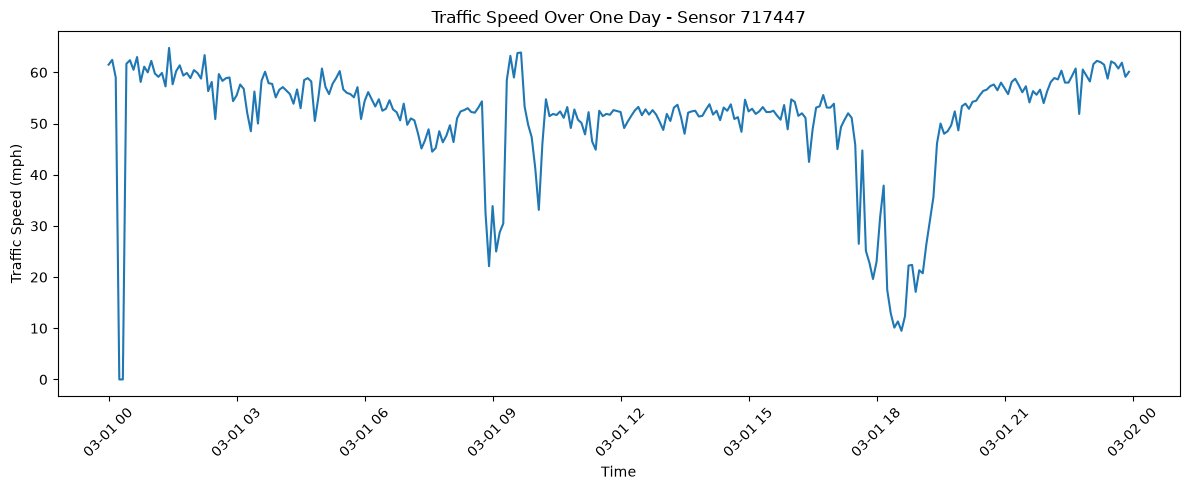

In [30]:

sensor = "717447"

plt.figure(figsize=(12, 5))

plt.plot(traffic_df.index[:288], traffic_df[sensor][:288])

plt.xlabel("Time")
plt.ylabel("Traffic Speed (mph)")
plt.title(f"Traffic Speed Over One Day - Sensor {sensor}")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [31]:

average_speed = traffic_df.mean(axis=1)

print("Average speed series:")
print(average_speed.head())

print("\nNumber of time points:", len(average_speed))

Average speed series:
2012-03-01 00:00:00    62.305038
2012-03-01 00:05:00    62.335816
2012-03-01 00:10:00    61.858149
2012-03-01 00:15:00     0.000000
2012-03-01 00:20:00     0.000000
dtype: float64

Number of time points: 34272


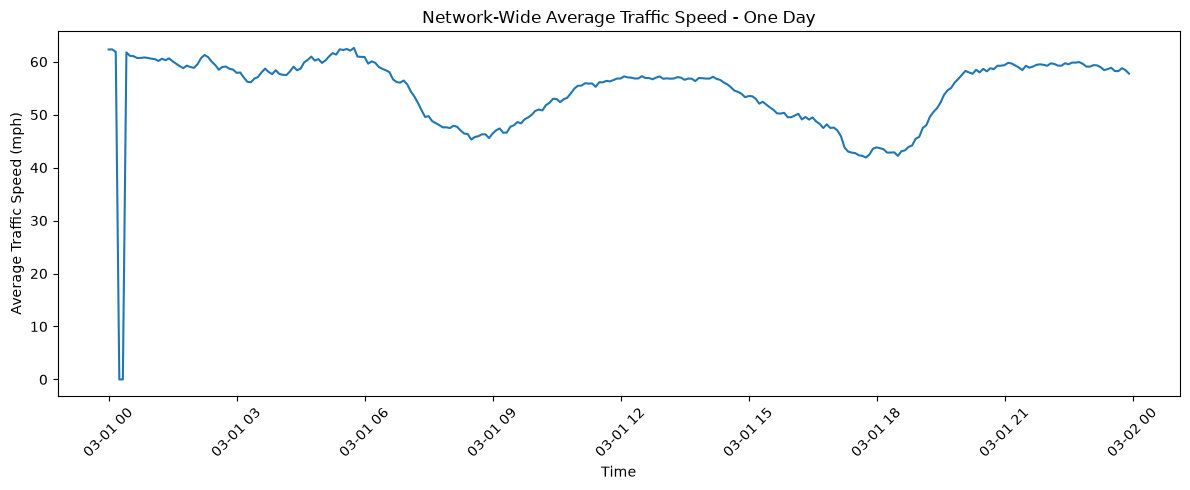

In [32]:

plt.figure(figsize=(12, 5))

plt.plot(
    average_speed.index[:288],
    average_speed.iloc[:288]
)

plt.xlabel("Time")
plt.ylabel("Average Traffic Speed (mph)")
plt.title("Network-Wide Average Traffic Speed - One Day")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [33]:

hourly_speed = traffic_df.groupby(traffic_df.index.hour).mean().mean(axis=1)

print("Average traffic speed by hour:")
print(hourly_speed)

Average traffic speed by hour:
0     56.321629
1     56.686634
2     55.079091
3     53.947426
4     55.014033
5     56.525704
6     54.735278
7     50.885707
8     48.602117
9     50.500531
10    52.363103
11    54.168524
12    53.490242
13    52.636549
14    51.779164
15    50.122288
16    48.296004
17    46.534521
18    48.991486
19    56.012438
20    59.828343
21    59.139055
22    58.723743
23    58.872898
dtype: float64


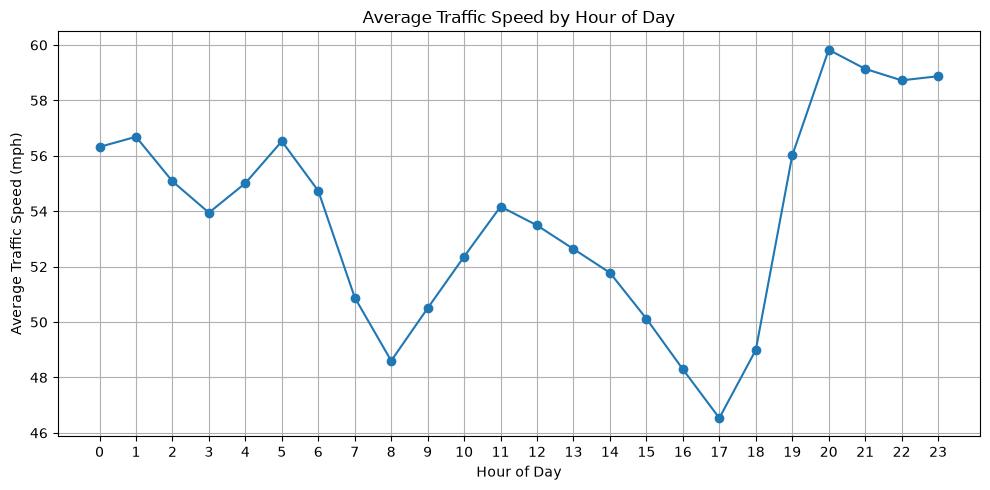

In [34]:

plt.figure(figsize=(10, 5))

plt.plot(hourly_speed.index, hourly_speed.values, marker="o")

plt.xlabel("Hour of Day")
plt.ylabel("Average Traffic Speed (mph)")
plt.title("Average Traffic Speed by Hour of Day")

plt.xticks(range(24))
plt.grid(True)

plt.tight_layout()
plt.show()

In [35]:

zero_count_per_timestamp = (traffic_df == 0).sum(axis=1)

print("Maximum number of sensors with zero speed at one timestamp:")
print(zero_count_per_timestamp.max())

print("\nAverage number of zero-speed sensors per timestamp:")
print(round(zero_count_per_timestamp.mean(), 2))

print("\nTimestamps where all sensors have zero speed:")
print((zero_count_per_timestamp == len(traffic_df.columns)).sum())

Maximum number of sensors with zero speed at one timestamp:
207

Average number of zero-speed sensors per timestamp:
16.79

Timestamps where all sensors have zero speed:
2148
